# 05 — Modeling and Benchmarking (Kalimantan Development)

This notebook evaluates the fire-activity forecasting dataset produced by Notebook 04.

**Development scope:** Kalimantan only.

## Objective

Predict:

`target_fire_active_t1`

which represents whether fire activity is observed in the same cell on the following day.

## Evaluation design

- Primary metric: **PR-AUC (Average Precision)**
- Secondary metrics: Precision, Recall, F1-score, Accuracy
- Temporal split:
  - Train: 2026-05-08 to 2026-07-31
  - Validation: 2026-08-01 to 2026-08-31
  - Test: 2026-09-01 to 2026-09-10
- Hyperparameter tuning uses only an earlier temporal sub-split:
  - Tuning train: 2026-05-08 to 2026-06-30
  - Tuning validation: 2026-07-01 to 2026-07-31
- The August validation set is kept untouched during tuning.
- The September test set is used only after the model/feature configuration is selected.

## Fair model comparison

The main model benchmark uses the **same 20 features** for every model:

- 10 Fire History features
- 10 Weather features

AQ, FWI, and spatial-lag features are evaluated separately in controlled experiments.

## Models

Baseline / benchmark:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost

Additional nonlinear candidate:
- CatBoost

The purpose of CatBoost is to test whether a nonlinear boosting model can address limitations of a linear decision boundary without changing the feature set or temporal split.


In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "karhut_ml_dataset_kalimantan.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Run Notebook 04 first."
    )


Project root: c:\Users\Asus\Documents\skripsi-karhut
Dataset: c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_dataset_kalimantan.csv


In [31]:
ml_data = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

ml_data = (
    ml_data
    .sort_values(["cell_id", "date"])
    .reset_index(drop=True)
)

print("Dataset shape:", ml_data.shape)
print("Date range:", ml_data["date"].min().date(), "→", ml_data["date"].max().date())
print("Unique cells:", ml_data["cell_id"].nunique())

display(ml_data.head())


Dataset shape: (34272, 29)
Date range: 2026-05-08 → 2026-09-10
Unique cells: 272


,region,cell_id,date,grid_lat,grid_lon,weather_lat,weather_lon,weather_distance_km,fire_count_lag1,fire_count_lag3,...,temperature_max,relative_humidity_mean,precipitation_sum,boundary_layer_height_mean,vapour_pressure_deficit_mean,wind_speed_mean,wind_speed_max,wind_u_mean,wind_v_mean,target_fire_active_t1
0,Kalimantan,Kalimantan_-0.75_108.00,2026-05-08,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,28.9,82.750000,47.8,322.083333,0.630833,6.679167,15.0,-3.475577,3.189461,0.0
1,Kalimantan,Kalimantan_-0.75_108.00,2026-05-09,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,29.5,79.916667,6.2,430.416667,0.772500,9.020833,14.5,5.493204,5.629225,0.0
2,Kalimantan,Kalimantan_-0.75_108.00,2026-05-10,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,31.1,62.500000,0.0,643.125000,1.646667,3.325000,7.1,-0.728517,-0.354466,0.0
3,Kalimantan,Kalimantan_-0.75_108.00,2026-05-11,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,31.2,61.375000,0.0,780.208333,1.700417,7.683333,14.7,-0.473697,-4.136161,0.0
4,Kalimantan,Kalimantan_-0.75_108.00,2026-05-12,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,30.5,70.125000,1.2,545.625000,1.235417,11.966667,20.5,-10.974184,1.647696,0.0


## 1. Define the 20-feature benchmark

These features must remain identical across the main model comparison.


In [32]:
fire_history_features = [
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7"
]

weather_features = [
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean"
]

features_20 = fire_history_features + weather_features
target_col = "target_fire_active_t1"

assert len(fire_history_features) == 10
assert len(weather_features) == 10
assert len(features_20) == 20
assert target_col not in features_20

missing_features = set(features_20 + [target_col]) - set(ml_data.columns)

if missing_features:
    raise ValueError(f"Missing required columns: {sorted(missing_features)}")

print("20 benchmark features:")
for i, f in enumerate(features_20, 1):
    print(f"{i:02d}. {f}")


20 benchmark features:
01. fire_count_lag1
02. fire_count_lag3
03. fire_count_lag7
04. frp_sum_lag1
05. frp_sum_lag3
06. frp_sum_lag7
07. fire_count_roll3
08. fire_count_roll7
09. frp_sum_roll3
10. frp_sum_roll7
11. temperature_mean
12. temperature_max
13. relative_humidity_mean
14. precipitation_sum
15. boundary_layer_height_mean
16. vapour_pressure_deficit_mean
17. wind_speed_mean
18. wind_speed_max
19. wind_u_mean
20. wind_v_mean


## 2. Temporal train / validation / test split

No random split is used because the task is forecasting over time.


In [33]:
train_data = ml_data[
    ml_data["date"] < "2026-08-01"
].copy()

val_data = ml_data[
    (ml_data["date"] >= "2026-08-01") &
    (ml_data["date"] < "2026-09-01")
].copy()

test_data = ml_data[
    ml_data["date"] >= "2026-09-01"
].copy()

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Start": [
        train_data["date"].min(),
        val_data["date"].min(),
        test_data["date"].min()
    ],
    "End": [
        train_data["date"].max(),
        val_data["date"].max(),
        test_data["date"].max()
    ],
    "Rows": [
        len(train_data),
        len(val_data),
        len(test_data)
    ],
    "Positive Rate": [
        train_data[target_col].mean(),
        val_data[target_col].mean(),
        test_data[target_col].mean()
    ]
})

display(split_summary)


,Split,Start,End,Rows,Positive Rate
0,Train,2026-05-08,2026-07-31,23120,0.110424
1,Validation,2026-08-01,2026-08-31,8432,0.339184
2,Test,2026-09-01,2026-09-10,2720,0.319485


In [34]:
X_train = train_data[features_20]
y_train = train_data[target_col].astype(int)

X_val = val_data[features_20]
y_val = val_data[target_col].astype(int)

X_test = test_data[features_20]
y_test = test_data[target_col].astype(int)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


X_train: (23120, 20)
X_val  : (8432, 20)
X_test : (2720, 20)


## 3. Evaluation helper

PR-AUC is calculated from predicted probabilities. Threshold-based metrics are calculated separately at a specified operating threshold.


In [35]:
def metric_dict(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Threshold": threshold
    }


def print_metrics(name, metrics):
    print(f"=== {name} ===")
    for key, value in metrics.items():
        if isinstance(value, (float, np.floating)):
            print(f"{key:10s}: {value:.6f}")
        else:
            print(f"{key:10s}: {value}")


def find_best_f1_threshold(y_true, y_prob, start=0.30, stop=0.81, step=0.01):
    rows = []

    for threshold in np.arange(start, stop, step):
        threshold = round(float(threshold), 2)
        y_pred = (y_prob >= threshold).astype(int)

        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0)
        })

    result = pd.DataFrame(rows)

    # Deterministic tie-breaking:
    # highest F1, then highest recall, then lowest threshold.
    result = result.sort_values(
        ["F1", "Recall", "Threshold"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return result


def evaluate_test(model, X, y, threshold):
    prob = model.predict_proba(X)[:, 1]
    metrics = metric_dict(y, prob, threshold)
    cm = confusion_matrix(y, (prob >= threshold).astype(int))
    return metrics, cm, prob


## 4. Baseline benchmark — Logistic Regression

Logistic Regression is the linear baseline.

`class_weight="balanced"` is used because the training target is imbalanced.


In [36]:
lr_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_baseline.fit(X_train, y_train)

lr_val_prob = lr_baseline.predict_proba(X_val)[:, 1]
lr_val_metrics_05 = metric_dict(y_val, lr_val_prob, threshold=0.5)

print_metrics("Logistic Regression — Validation @ 0.50", lr_val_metrics_05)


=== Logistic Regression — Validation @ 0.50 ===
PR-AUC    : 0.901149
Precision : 0.677419
Recall    : 0.925175
F1        : 0.782146
Accuracy  : 0.825190
Threshold : 0.500000


## 5. Random Forest benchmark


In [37]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

rf_val_prob = rf_baseline.predict_proba(X_val)[:, 1]
rf_val_metrics_05 = metric_dict(y_val, rf_val_prob, threshold=0.5)

print_metrics("Random Forest — Validation @ 0.50", rf_val_metrics_05)


=== Random Forest — Validation @ 0.50 ===
PR-AUC    : 0.837577
Precision : 0.799775
Recall    : 0.747203
F1        : 0.772596
Accuracy  : 0.850806
Threshold : 0.500000


## 6. Gradient Boosting benchmark


In [38]:
gb_baseline = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb_baseline.fit(
    X_train,
    y_train,
    sample_weight=gb_sample_weights
)

gb_val_prob = gb_baseline.predict_proba(X_val)[:, 1]
gb_val_metrics_05 = metric_dict(y_val, gb_val_prob, threshold=0.5)

print_metrics("Gradient Boosting — Validation @ 0.50", gb_val_metrics_05)


=== Gradient Boosting — Validation @ 0.50 ===
PR-AUC    : 0.878306
Precision : 0.684303
Recall    : 0.949650
F1        : 0.795431
Accuracy  : 0.834322
Threshold : 0.500000


## 7. XGBoost benchmark

The positive-class weight is calculated from the **training split only**.


In [39]:
from xgboost import XGBClassifier

neg_train = (y_train == 0).sum()
pos_train = (y_train == 1).sum()
scale_pos_weight_train = neg_train / pos_train

print("Training negatives:", neg_train)
print("Training positives:", pos_train)
print("scale_pos_weight:", scale_pos_weight_train)

xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_train,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_baseline.fit(X_train, y_train)

xgb_val_prob = xgb_baseline.predict_proba(X_val)[:, 1]
xgb_val_metrics_05 = metric_dict(y_val, xgb_val_prob, threshold=0.5)

print_metrics("XGBoost — Validation @ 0.50", xgb_val_metrics_05)


Training negatives: 20567
Training positives: 2553
scale_pos_weight: 8.056012534273403
=== XGBoost — Validation @ 0.50 ===
PR-AUC    : 0.867799
Precision : 0.685176
Recall    : 0.940559
F1        : 0.792809
Accuracy  : 0.833254
Threshold : 0.500000


## 8. Benchmark comparison

This comparison is fair because all four models use the same 20 features and the same temporal split.


In [40]:
benchmark_untuned = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_val_metrics_05},
    {"Model": "Random Forest", **rf_val_metrics_05},
    {"Model": "Gradient Boosting", **gb_val_metrics_05},
    {"Model": "XGBoost", **xgb_val_metrics_05}
])

display(
    benchmark_untuned[
        ["Model", "PR-AUC", "Precision", "Recall", "F1", "Accuracy", "Threshold"]
    ]
)


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,Logistic Regression,0.901149,0.677419,0.925175,0.782146,0.825190,0.5
1,Random Forest,0.837577,0.799775,0.747203,0.772596,0.850806,0.5
2,Gradient Boosting,0.878306,0.684303,0.949650,0.795431,0.834322,0.5
3,XGBoost,0.867799,0.685176,0.940559,0.792809,0.833254,0.5


## 9. Temporal hyperparameter tuning

Tuning is performed on an earlier part of the training period so that August remains an untouched validation set.

```text
Tuning train      : 2026-05-08 → 2026-06-30
Tuning validation : 2026-07-01 → 2026-07-31
Final validation  : August 2026
Test              : September 2026
```

The tuning objective is PR-AUC.


In [41]:
tune_train = ml_data[
    (ml_data["date"] >= "2026-05-08") &
    (ml_data["date"] < "2026-07-01")
].copy()

tune_val = ml_data[
    (ml_data["date"] >= "2026-07-01") &
    (ml_data["date"] < "2026-08-01")
].copy()

X_tune_train = tune_train[features_20]
y_tune_train = tune_train[target_col].astype(int)

X_tune_val = tune_val[features_20]
y_tune_val = tune_val[target_col].astype(int)

print("Tuning train:", X_tune_train.shape)
print("Tuning val  :", X_tune_val.shape)
print("Tuning train positive rate:", y_tune_train.mean())
print("Tuning val positive rate  :", y_tune_val.mean())


Tuning train: (14688, 20)
Tuning val  : (8432, 20)
Tuning train positive rate: 0.08272058823529412
Tuning val positive rate  : 0.15868121442125238


### 9.1 Random Forest tuning


In [42]:
rf_configs = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 2},
    {"n_estimators": 400, "max_depth": 15, "min_samples_leaf": 2}
]

rf_tuning_rows = []

for config in rf_configs:
    model = RandomForestClassifier(
        **config,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_tune_train, y_tune_train)
    prob = model.predict_proba(X_tune_val)[:, 1]

    rf_tuning_rows.append({
        **config,
        "PR-AUC": average_precision_score(y_tune_val, prob)
    })

rf_tuning_df = pd.DataFrame(rf_tuning_rows).sort_values(
    "PR-AUC", ascending=False
).reset_index(drop=True)

display(rf_tuning_df)


,n_estimators,max_depth,min_samples_leaf,PR-AUC
0,300,20.0,2,0.517658
1,400,15.0,2,0.500310
2,200,NaN,1,0.472891
3,300,10.0,1,0.465433


### 9.2 Gradient Boosting tuning


In [43]:
gb_configs = [
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.10, "max_depth": 2},
    {"n_estimators": 200, "learning_rate": 0.03, "max_depth": 3}
]

gb_tuning_rows = []

gb_weights_tune = compute_sample_weight(
    class_weight="balanced",
    y=y_tune_train
)

for config in gb_configs:
    model = GradientBoostingClassifier(
        **config,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_tune_train,
        y_tune_train,
        sample_weight=gb_weights_tune
    )

    prob = model.predict_proba(X_tune_val)[:, 1]

    gb_tuning_rows.append({
        **config,
        "PR-AUC": average_precision_score(y_tune_val, prob)
    })

gb_tuning_df = pd.DataFrame(gb_tuning_rows).sort_values(
    "PR-AUC", ascending=False
).reset_index(drop=True)

display(gb_tuning_df)


,n_estimators,learning_rate,max_depth,PR-AUC
0,200,0.05,2,0.564243
1,100,0.10,2,0.562319
2,100,0.05,2,0.557539
3,200,0.03,3,0.528316


### 9.3 XGBoost tuning


In [44]:
xgb_configs = [
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 3
    },
    {
        "n_estimators": 400,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 3
    },
    {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 3
    },
    {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.02,
        "min_child_weight": 5
    }
]

neg_tune = (y_tune_train == 0).sum()
pos_tune = (y_tune_train == 1).sum()
scale_pos_weight_tune = neg_tune / pos_tune

xgb_tuning_rows = []

for config in xgb_configs:
    model = XGBClassifier(
        **config,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_tune,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_tune_train, y_tune_train)

    prob = model.predict_proba(X_tune_val)[:, 1]

    xgb_tuning_rows.append({
        **config,
        "PR-AUC": average_precision_score(y_tune_val, prob)
    })

xgb_tuning_df = pd.DataFrame(xgb_tuning_rows).sort_values(
    "PR-AUC", ascending=False
).reset_index(drop=True)

display(xgb_tuning_df)


,n_estimators,max_depth,learning_rate,min_child_weight,PR-AUC
0,500,3,0.02,5,0.572901
1,300,3,0.05,3,0.562501
2,400,3,0.03,3,0.562427
3,400,4,0.03,3,0.552395


## 10. Retrain tuned benchmark models on the full training period

After selecting hyperparameters using the earlier tuning split, each selected model is retrained on the complete May–July training period and evaluated on August.


In [45]:
best_rf_config = rf_tuning_df.iloc[0].to_dict()
best_gb_config = gb_tuning_df.iloc[0].to_dict()
best_xgb_config = xgb_tuning_df.iloc[0].to_dict()

best_rf_config = {
    "n_estimators": int(best_rf_config["n_estimators"]),
    "max_depth": None if pd.isna(best_rf_config["max_depth"]) else int(best_rf_config["max_depth"]),
    "min_samples_leaf": int(best_rf_config["min_samples_leaf"])
}

best_gb_config = {
    "n_estimators": int(best_gb_config["n_estimators"]),
    "learning_rate": float(best_gb_config["learning_rate"]),
    "max_depth": int(best_gb_config["max_depth"])
}

best_xgb_config = {
    "n_estimators": int(best_xgb_config["n_estimators"]),
    "max_depth": int(best_xgb_config["max_depth"]),
    "learning_rate": float(best_xgb_config["learning_rate"]),
    "min_child_weight": int(best_xgb_config["min_child_weight"])
}

print("Best RF :", best_rf_config)
print("Best GB :", best_gb_config)
print("Best XGB:", best_xgb_config)


Best RF : {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2}
Best GB : {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2}
Best XGB: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.02, 'min_child_weight': 5}


In [46]:
# Tuned Random Forest
rf_tuned = RandomForestClassifier(
    **best_rf_config,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)
rf_tuned_val_prob = rf_tuned.predict_proba(X_val)[:, 1]
rf_tuned_val_metrics = metric_dict(y_val, rf_tuned_val_prob, 0.5)

# Tuned Gradient Boosting
gb_tuned = GradientBoostingClassifier(
    **best_gb_config,
    random_state=RANDOM_STATE
)
gb_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)
gb_tuned.fit(
    X_train,
    y_train,
    sample_weight=gb_weights_train
)
gb_tuned_val_prob = gb_tuned.predict_proba(X_val)[:, 1]
gb_tuned_val_metrics = metric_dict(y_val, gb_tuned_val_prob, 0.5)

# Tuned XGBoost
xgb_tuned = XGBClassifier(
    **best_xgb_config,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_train,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_tuned.fit(X_train, y_train)
xgb_tuned_val_prob = xgb_tuned.predict_proba(X_val)[:, 1]
xgb_tuned_val_metrics = metric_dict(y_val, xgb_tuned_val_prob, 0.5)

print_metrics("Tuned Random Forest — Validation @ 0.50", rf_tuned_val_metrics)
print()
print_metrics("Tuned Gradient Boosting — Validation @ 0.50", gb_tuned_val_metrics)
print()
print_metrics("Tuned XGBoost — Validation @ 0.50", xgb_tuned_val_metrics)


=== Tuned Random Forest — Validation @ 0.50 ===
PR-AUC    : 0.853942
Precision : 0.763805
Recall    : 0.836713
F1        : 0.798598
Accuracy  : 0.856855
Threshold : 0.500000

=== Tuned Gradient Boosting — Validation @ 0.50 ===
PR-AUC    : 0.893740
Precision : 0.694522
Recall    : 0.953147
F1        : 0.803537
Accuracy  : 0.841912
Threshold : 0.500000

=== Tuned XGBoost — Validation @ 0.50 ===
PR-AUC    : 0.894462
Precision : 0.685729
Recall    : 0.955944
F1        : 0.798598
Accuracy  : 0.836456
Threshold : 0.500000


## 11. Main benchmark table



In [47]:
benchmark_results = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_val_metrics_05},
    {"Model": "Random Forest (Tuned)", **rf_tuned_val_metrics},
    {"Model": "Gradient Boosting (Tuned)", **gb_tuned_val_metrics},
    {"Model": "XGBoost (Tuned)", **xgb_tuned_val_metrics}
])

benchmark_results = benchmark_results[
    ["Model", "PR-AUC", "Precision", "Recall", "F1", "Accuracy", "Threshold"]
]

display(benchmark_results)


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,Logistic Regression,0.901149,0.677419,0.925175,0.782146,0.825190,0.5
1,Random Forest (Tuned),0.853942,0.763805,0.836713,0.798598,0.856855,0.5
2,Gradient Boosting (Tuned),0.893740,0.694522,0.953147,0.803537,0.841912,0.5
3,XGBoost (Tuned),0.894462,0.685729,0.955944,0.798598,0.836456,0.5


## 12. CatBoost — nonlinear candidate

CatBoost is evaluated using the **same 20 features and the same temporal protocol**.

It is intentionally tested after the established benchmark because the research question is whether a nonlinear boosting model can improve on the linear baseline without changing the input information.

In [48]:
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print("CatBoost import: OK")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost is not installed.")
    print("Install once with: pip install catboost")


CatBoost import: OK


In [49]:
catboost_tuning_results = pd.DataFrame()

if CATBOOST_AVAILABLE:

    cat_configs = [
        {
            "iterations": 300,
            "depth": 4,
            "learning_rate": 0.05,
            "l2_leaf_reg": 3
        },
        {
            "iterations": 500,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 3
        },
        {
            "iterations": 500,
            "depth": 6,
            "learning_rate": 0.03,
            "l2_leaf_reg": 5
        },
        {
            "iterations": 700,
            "depth": 5,
            "learning_rate": 0.02,
            "l2_leaf_reg": 5
        }
    ]

    cat_neg = (y_tune_train == 0).sum()
    cat_pos = (y_tune_train == 1).sum()
    cat_scale_pos_weight = cat_neg / cat_pos

    rows = []

    for config in cat_configs:

        model = CatBoostClassifier(
            **config,
            loss_function="Logloss",
            eval_metric="PRAUC",
            scale_pos_weight=cat_scale_pos_weight,
            random_seed=RANDOM_STATE,
            verbose=False,
            thread_count=-1,
            allow_writing_files=False
        )

        model.fit(
            X_tune_train,
            y_tune_train
        )

        prob = model.predict_proba(X_tune_val)[:, 1]

        rows.append({
            **config,
            "PR-AUC": average_precision_score(y_tune_val, prob)
        })

    catboost_tuning_results = (
        pd.DataFrame(rows)
        .sort_values("PR-AUC", ascending=False)
        .reset_index(drop=True)
    )

    display(catboost_tuning_results)
else:
    print("Skipping CatBoost tuning because the package is unavailable.")


,iterations,depth,learning_rate,l2_leaf_reg,PR-AUC
0,700,5,0.02,5,0.572016
1,500,6,0.03,5,0.563716
2,300,4,0.05,3,0.553326
3,500,5,0.03,3,0.549292


In [50]:
catboost_selected = None
catboost_val_prob = None
catboost_val_metrics = None

if CATBOOST_AVAILABLE and not catboost_tuning_results.empty:

    best_cat = catboost_tuning_results.iloc[0]

    catboost_selected = {
        "iterations": int(best_cat["iterations"]),
        "depth": int(best_cat["depth"]),
        "learning_rate": float(best_cat["learning_rate"]),
        "l2_leaf_reg": float(best_cat["l2_leaf_reg"])
    }

    catboost_final = CatBoostClassifier(
        **catboost_selected,
        loss_function="Logloss",
        eval_metric="PRAUC",
        scale_pos_weight=scale_pos_weight_train,
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1,
        allow_writing_files=False
    )

    catboost_final.fit(
        X_train,
        y_train
    )

    catboost_val_prob = catboost_final.predict_proba(X_val)[:, 1]

    catboost_val_metrics = metric_dict(
        y_val,
        catboost_val_prob,
        threshold=0.5
    )

    print("Selected CatBoost configuration:")
    print(catboost_selected)
    print()
    print_metrics(
        "CatBoost — Validation @ 0.50",
        catboost_val_metrics
    )
else:
    print("CatBoost final validation skipped.")


Selected CatBoost configuration:
{'iterations': 700, 'depth': 5, 'learning_rate': 0.02, 'l2_leaf_reg': 5.0}

=== CatBoost — Validation @ 0.50 ===
PR-AUC    : 0.893969
Precision : 0.689769
Recall    : 0.950000
F1        : 0.799235
Accuracy  : 0.838117
Threshold : 0.500000


## 13. Compare CatBoost with the established benchmark

The comparison is descriptive. No model is declared superior merely from a different feature set or split.


In [51]:
all_validation_results = benchmark_results.copy()

if catboost_val_metrics is not None:
    cat_row = pd.DataFrame([{
        "Model": "CatBoost (Tuned)",
        **catboost_val_metrics
    }])

    all_validation_results = pd.concat(
        [all_validation_results, cat_row],
        ignore_index=True
    )

display(
    all_validation_results[
        ["Model", "PR-AUC", "Precision", "Recall", "F1", "Accuracy", "Threshold"]
    ]
)


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,Logistic Regression,0.901149,0.677419,0.925175,0.782146,0.825190,0.5
1,Random Forest (Tuned),0.853942,0.763805,0.836713,0.798598,0.856855,0.5
2,Gradient Boosting (Tuned),0.893740,0.694522,0.953147,0.803537,0.841912,0.5
3,XGBoost (Tuned),0.894462,0.685729,0.955944,0.798598,0.836456,0.5
4,CatBoost (Tuned),0.893969,0.689769,0.950000,0.799235,0.838117,0.5


## 14. Feature ablation — Logistic Regression

Feature ablation answers a different question from model benchmarking:

> How much does the input information change predictive performance?

The three controlled groups are:

- A: Fire History only — 10 features
- B: Fire History + Weather — 20 features
- C: Fire History + Weather + AQ — 25 features

All use the same Logistic Regression pipeline and the same temporal validation set.


In [52]:
aq_features = [
    "pm2_5_mean",
    "pm2_5_max",
    "aerosol_optical_depth_mean",
    "carbon_monoxide_mean",
    "formaldehyde_mean"
]

ablation_features = {
    "A — Fire History Only": fire_history_features,
    "B — Fire History + Weather": features_20,
    "C — Fire History + Weather + AQ": features_20 + aq_features
}

ablation_rows = []

for name, cols in ablation_features.items():

    required = set(cols + [target_col])

    if not required.issubset(ml_data.columns):
        print(f"Skipping {name}: missing columns.")
        continue

    # Drop only rows needed for this feature set.
    train_ab = train_data.dropna(subset=cols + [target_col])
    val_ab = val_data.dropna(subset=cols + [target_col])

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    model.fit(
        train_ab[cols],
        train_ab[target_col].astype(int)
    )

    prob = model.predict_proba(
        val_ab[cols]
    )[:, 1]

    metrics = metric_dict(
        val_ab[target_col].astype(int),
        prob,
        threshold=0.5
    )

    ablation_rows.append({
        "Experiment": name,
        "Features": len(cols),
        **metrics
    })

ablation_df = pd.DataFrame(ablation_rows)

display(ablation_df)


Skipping C — Fire History + Weather + AQ: missing columns.


,Experiment,Features,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,A — Fire History Only,10,0.896141,0.767787,0.886713,0.822976,0.870612,0.5
1,B — Fire History + Weather,20,0.901149,0.677419,0.925175,0.782146,0.825190,0.5


## 15. Operating threshold for the selected LR feature set

PR-AUC does not depend on a single classification threshold.

For the selected Logistic Regression + Fire History + Weather configuration, threshold is tuned **only on August validation** using F1 as the operating-point criterion.

The test set remains untouched.


In [53]:
lr_b = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_b.fit(
    X_train,
    y_train
)

lr_b_val_prob = lr_b.predict_proba(X_val)[:, 1]

threshold_df = find_best_f1_threshold(
    y_val,
    lr_b_val_prob,
    start=0.30,
    stop=0.81,
    step=0.01
)

best_lr_threshold = float(
    threshold_df.iloc[0]["Threshold"]
)

print("Selected LR operating threshold:", best_lr_threshold)
display(threshold_df.head(10))


Selected LR operating threshold: 0.69


,Threshold,Precision,Recall,F1
0,0.69,0.788742,0.852448,0.819358
1,0.68,0.784138,0.857343,0.819108
2,0.70,0.792348,0.847203,0.818858
3,0.72,0.800670,0.835664,0.817793
4,0.67,0.778199,0.861189,0.817593
5,0.73,0.803445,0.831818,0.817385
6,0.74,0.806122,0.828671,0.817241
7,0.75,0.810392,0.823427,0.816857
8,0.77,0.818981,0.814685,0.816827
9,0.71,0.794965,0.839161,0.816465


## 16. Final LR benchmark evaluation on the untouched test set

The model is already selected from the training/validation process. The September test set is now used once for final evaluation.


In [54]:
lr_test_metrics, lr_test_cm, lr_test_prob = evaluate_test(
    lr_b,
    X_test,
    y_test,
    best_lr_threshold
)

print_metrics(
    "Final Logistic Regression — Test",
    lr_test_metrics
)

print("\nConfusion Matrix:")
print(lr_test_cm)


=== Final Logistic Regression — Test ===
PR-AUC    : 0.896144
Precision : 0.748544
Recall    : 0.887227
F1        : 0.812006
Accuracy  : 0.868750
Threshold : 0.690000

Confusion Matrix:
[[1592  259]
 [  98  771]]


## 17. Final candidate test evaluation — CatBoost

CatBoost is evaluated on the test set only if it was available and selected during the development/validation stage.

No CatBoost test result is generated if CatBoost was not installed.


In [55]:
catboost_test_metrics = None
catboost_test_cm = None
catboost_test_prob = None

if catboost_final is not None:

    cat_threshold_df = find_best_f1_threshold(
        y_val,
        catboost_val_prob,
        start=0.30,
        stop=0.81,
        step=0.01
    )

    cat_best_threshold = float(
        cat_threshold_df.iloc[0]["Threshold"]
    )

    catboost_test_metrics, catboost_test_cm, catboost_test_prob = evaluate_test(
        catboost_final,
        X_test,
        y_test,
        cat_best_threshold
    )

    print("CatBoost selected operating threshold:", cat_best_threshold)
    print()
    print_metrics(
        "CatBoost — Test",
        catboost_test_metrics
    )

    print("\nConfusion Matrix:")
    print(catboost_test_cm)

else:
    print("CatBoost test evaluation skipped.")


CatBoost selected operating threshold: 0.74

=== CatBoost — Test ===
PR-AUC    : 0.903152
Precision : 0.732902
Recall    : 0.912543
F1        : 0.812916
Accuracy  : 0.865809
Threshold : 0.740000

Confusion Matrix:
[[1562  289]
 [  76  793]]


## 18. Final validation and test summary

This table keeps validation and test results clearly separated.

The test set should not be used to choose the model.


In [56]:
final_summary_rows = [
    {
        "Model": "Logistic Regression",
        "Validation PR-AUC": average_precision_score(y_val, lr_b_val_prob),
        "Test PR-AUC": lr_test_metrics["PR-AUC"],
        "Test Precision": lr_test_metrics["Precision"],
        "Test Recall": lr_test_metrics["Recall"],
        "Test F1": lr_test_metrics["F1"],
        "Test Accuracy": lr_test_metrics["Accuracy"],
        "Test Threshold": lr_test_metrics["Threshold"]
    }
]

if catboost_val_metrics is not None and catboost_test_metrics is not None:
    final_summary_rows.append({
        "Model": "CatBoost",
        "Validation PR-AUC": catboost_val_metrics["PR-AUC"],
        "Test PR-AUC": catboost_test_metrics["PR-AUC"],
        "Test Precision": catboost_test_metrics["Precision"],
        "Test Recall": catboost_test_metrics["Recall"],
        "Test F1": catboost_test_metrics["F1"],
        "Test Accuracy": catboost_test_metrics["Accuracy"],
        "Test Threshold": catboost_test_metrics["Threshold"]
    })

final_summary = pd.DataFrame(final_summary_rows)

display(final_summary)


,Model,Validation PR-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1,Test Accuracy,Test Threshold
0,Logistic Regression,0.901149,0.896144,0.748544,0.887227,0.812006,0.868750,0.69
1,CatBoost,0.893969,0.903152,0.732902,0.912543,0.812916,0.865809,0.74


## 19. Logistic Regression interpretation — permutation importance

Permutation importance is calculated on the August validation set using PR-AUC.

This is a predictive importance diagnostic, **not a causal effect estimate**.


In [57]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lr_b,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": features_20,
    "Importance_Mean": perm.importances_mean,
    "Importance_STD": perm.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

display(perm_df.head(20))


,Feature,Importance_Mean,Importance_STD
0,fire_count_roll7,0.507170,0.006293
1,fire_count_lag1,0.148149,0.004513
2,fire_count_roll3,0.139620,0.004943
3,vapour_pressure_deficit_mean,0.081412,0.001163
4,relative_humidity_mean,0.061208,0.001329
5,frp_sum_roll7,0.035672,0.002627
6,fire_count_lag7,0.032157,0.001721
7,temperature_max,0.025928,0.000973
8,frp_sum_roll3,0.021197,0.002530
9,frp_sum_lag1,0.009647,0.001732


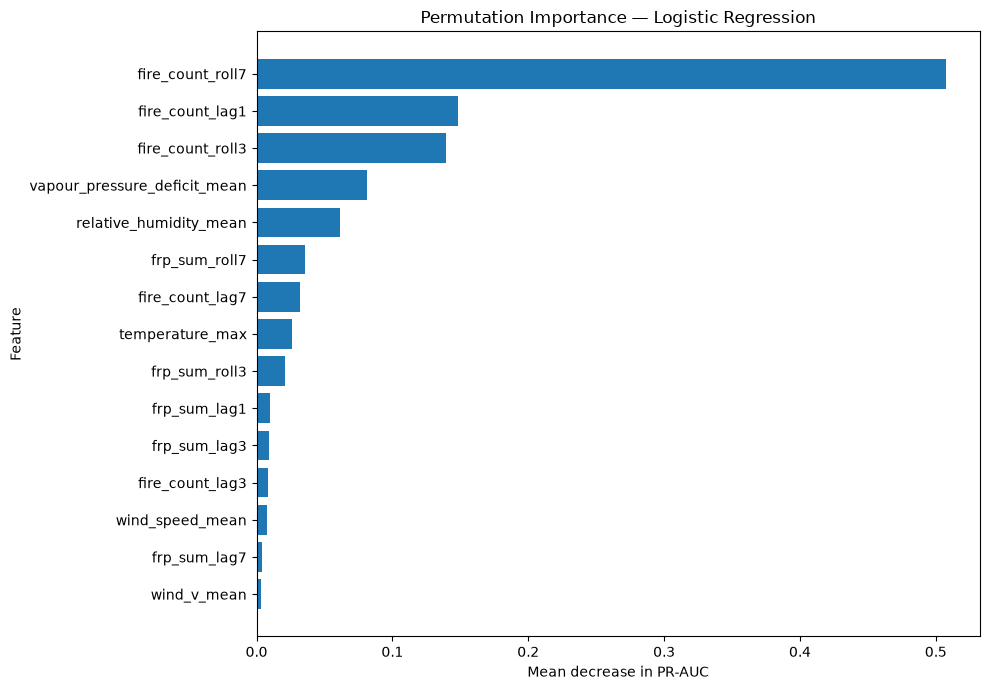

In [58]:
top_perm = (
    perm_df
    .head(15)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance_Mean"]
)

plt.xlabel("Mean decrease in PR-AUC")
plt.ylabel("Feature")
plt.title("Permutation Importance — Logistic Regression")
plt.tight_layout()
plt.show()


## 20. Save model results

The outputs are saved as CSV files for reproducibility and later thesis reporting.


In [59]:
RESULTS_DIR = PROJECT_ROOT / "data" / "processed" / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

benchmark_output = RESULTS_DIR / "benchmark_validation_results.csv"
ablation_output = RESULTS_DIR / "ablation_validation_results.csv"
final_output = RESULTS_DIR / "final_test_results.csv"
perm_output = RESULTS_DIR / "lr_permutation_importance.csv"

benchmark_results.to_csv(
    benchmark_output,
    index=False
)

ablation_df.to_csv(
    ablation_output,
    index=False
)

final_summary.to_csv(
    final_output,
    index=False
)

perm_df.to_csv(
    perm_output,
    index=False
)

print("Saved:")
print(benchmark_output)
print(ablation_output)
print(final_output)
print(perm_output)


Saved:
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\benchmark_validation_results.csv
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\ablation_validation_results.csv
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\final_test_results.csv
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\lr_permutation_importance.csv


# Notebook 05 — Final Notes

### Main benchmark

All primary models are compared on the identical 20-feature dataset and identical temporal validation period.

### Feature ablation

Feature ablation is reported separately from model benchmarking.

### CatBoost

CatBoost is an additional nonlinear candidate. Its test evaluation is performed only after the August validation stage.

### Important interpretation

A model that obtains a higher metric on one particular dataset does not establish a universal superiority. The result applies to this Kalimantan development dataset, temporal split, feature set, and evaluation protocol.

The fire target represents **observed FIRMS fire activity**, not absolute ground truth fire absence/presence.

### Next stage

Notebook 06 evaluates whether adding spatial-neighborhood information to the same forecasting setup provides additional predictive value.
